# 06 — `infer`

```
infer.py
========
Inference YOLO26 (object detection) pada satu gambar, folder gambar, atau video.

Alur:
  - validasi weights & source
  - muat model custom
  - prediksi (save gambar/video beranotasi)
  - hitung jumlah objek terdeteksi per kelas
  - tulis ringkasan inference

Jalankan dari ROOT project (Windows):
    python src/infer.py --weights runs/train/helmet_yolo26s_baseline/weights/best.pt --source path/to/image.jpg --conf 0.25
    python src/infer.py --source path/to/folder         (folder gambar)
    python src/infer.py --source path/to/video.mp4      (video)
    python src/infer.py --source img.jpg --save-txt --save-conf --show
    python src/infer.py --source img.jpg --allow-cpu     (bila tanpa GPU)

Output (runs/infer/):
  predict/                 (gambar/video beranotasi; +labels bila --save-txt)
  inference_summary.txt    (ringkasan + hitungan per kelas)

Catatan: READ-ONLY terhadap file input (Ultralytics menulis salinan beranotasi
ke runs/infer/, tidak menyentuh berkas asli).
```

Notebook ini adalah versi notebook dari [`src/infer.py`](../src/infer.py). Jalankan sel berurutan dari atas.

## Setup

In [2]:
# === Setup — jalankan sel ini lebih dulu ===
# Menemukan root project, menambahkan src/ ke sys.path, dan pindah (chdir) ke root
# agar semua path relatif (dataset/..., runs/...) berperilaku sama seperti
# menjalankan script dari root project.
import os, sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / "src").is_dir() and (d / "dataset").exists():
            return d
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
os.chdir(PROJECT_ROOT)
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("cwd         :", Path.cwd())

# === Auto-simpan grafik ke presentation_figures/ (otomatis tiap kali di-Run) ===
import matplotlib.pyplot as plt
_FIGDIR = PROJECT_ROOT / "presentation_figures"; _FIGDIR.mkdir(exist_ok=True)
_NB = "06_infer"; _cnt = {"n": 0}
for _old in _FIGDIR.glob(_NB + "_*.png"):
    try: _old.unlink()
    except Exception: pass
_orig_show = getattr(plt, "_orig_show", plt.show); plt._orig_show = _orig_show
def _autosave_show(*a, **k):
    _f = plt.gcf()
    if _f.get_axes():
        _cnt["n"] += 1
        try: _f.savefig(_FIGDIR / (_NB + "_%02d.png" % _cnt["n"]), dpi=130, bbox_inches="tight")
        except Exception: pass
    return _orig_show(*a, **k)
plt.show = _autosave_show

PROJECT_ROOT: d:\ML\test-code\construction-safety-helmet-yolo26
cwd         : d:\ML\test-code\construction-safety-helmet-yolo26


## Apa yang dilakukan notebook ini
**Tujuan:** menjalankan model pada **gambar / folder / video** baru dan menghitung objek per kelas.

**Alur:** validasi weights & source → deteksi tipe source → prediksi (simpan hasil beranotasi) → hitung deteksi per kelas → **peringatan K3 bila ada `No-Helmet`** → tulis ringkasan.

**Parameter penting:** `conf`, `iou`, opsi `--save-txt` / `--save-conf` / `--show`.

**Output → `runs/infer/predict/`** (gambar/video beranotasi) + `inference_summary.txt`.

**Saat presentasi:** **wajib** ganti `--source` ke file nyata sebelum menjalankan sel Run. Soroti hitungan per kelas & peringatan No-Helmet. Sel kode di bawah = isi lengkap [`src/infer.py`](../src/infer.py).

In [3]:
from __future__ import annotations

import argparse
import sys
from collections import defaultdict
from datetime import datetime
from pathlib import Path

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".wmv", ".flv", ".webm", ".m4v", ".mpg", ".mpeg"}

DEFAULTS = {
    "weights": "runs/train/helmet_yolo26s_baseline/weights/best.pt",
    "conf": 0.25,
    "iou": 0.5,
    "imgsz": 640,
    "device": "0",
    "project": "runs/infer",
    "name": "predict",
}


def _line(char: str = "=", width: int = 64) -> str:
    return char * width


# --------------------------------------------------------------------------- #
# Helpers
# --------------------------------------------------------------------------- #
def detect_source_type(source: Path) -> str:
    """Kembalikan 'folder' | 'image' | 'video' | 'unknown'."""
    if source.is_dir():
        return "folder"
    suf = source.suffix.lower()
    if suf in IMAGE_EXTS:
        return "image"
    if suf in VIDEO_EXTS:
        return "video"
    return "unknown"


def count_images_in_folder(folder: Path) -> int:
    return sum(1 for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)


def resolve_device(device_arg, allow_cpu: bool) -> tuple[object, bool, str]:
    """Return (device, ok, label). ok=False bila GPU diminta tapi CUDA tak ada & tanpa --allow-cpu."""
    try:
        import torch
    except ImportError as exc:
        raise RuntimeError("PyTorch belum terinstal. Instal PyTorch CUDA dari pytorch.org.") from exc

    if str(device_arg).lower() == "cpu":
        return "cpu", True, "CPU (diminta)"
    if torch.cuda.is_available():
        idx = int(device_arg) if str(device_arg).isdigit() else 0
        try:
            name = torch.cuda.get_device_properties(idx).name
        except Exception:
            name = "GPU"
        return device_arg, True, name
    if allow_cpu:
        print("[PERINGATAN] CUDA tidak tersedia. Memakai CPU (--allow-cpu); inference lebih lambat.")
        return "cpu", True, "CPU (fallback --allow-cpu)"
    return device_arg, False, ""


# --------------------------------------------------------------------------- #
# Summary
# --------------------------------------------------------------------------- #
def build_summary(args, src_type: str, device_label: str, n_units: int,
                  counts: dict, names: dict, save_dir: Path) -> str:
    unit_label = "frame" if src_type == "video" else "gambar"
    total = sum(counts.values())

    L: list[str] = []
    L.append(_line())
    L.append("RINGKASAN INFERENCE - YOLO26s (object detection)")
    L.append(_line())
    L.append(f"Waktu        : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    L.append(f"Weights      : {args.weights}")
    L.append(f"Source       : {args.source}  (tipe: {src_type})")
    L.append(f"imgsz        : {args.imgsz}   conf: {args.conf}   iou: {args.iou}")
    L.append(f"Device       : {args.device} ({device_label})")
    L.append(f"Diproses     : {n_units} {unit_label}")
    L.append(f"Opsi         : save_txt={args.save_txt}  save_conf={args.save_conf}  show={args.show}")
    L.append("")
    L.append("JUMLAH OBJEK TERDETEKSI PER KELAS")
    L.append("-" * 64)
    if total == 0:
        L.append("  (tidak ada objek terdeteksi)")
    else:
        # urutkan berdasar jumlah terbanyak
        for cid in sorted(counts, key=lambda c: counts[c], reverse=True):
            cname = names.get(cid, str(cid)) if isinstance(names, dict) else str(cid)
            L.append(f"  {cname:<16}: {counts[cid]}")
        L.append(f"  {'TOTAL':<16}: {total}")
    if src_type == "video":
        L.append("")
        L.append("  (catatan: untuk video, hitungan adalah total deteksi per-frame,")
        L.append("   sehingga objek yang sama bisa terhitung di banyak frame.)")

    # Catatan keselamatan ringan (No-Helmet)
    no_helmet = None
    if isinstance(names, dict):
        for cid, nm in names.items():
            if str(nm).lower().replace(" ", "") in ("no-helmet", "nohelmet"):
                no_helmet = counts.get(cid, 0)
    if no_helmet is not None and no_helmet > 0:
        L.append("")
        L.append(f"  [PERHATIAN K3] Terdeteksi {no_helmet} objek 'No-Helmet' "
                 "(indikasi potensi pelanggaran penggunaan helm).")

    L.append("")
    L.append(f"Hasil anotasi disimpan di: {save_dir}")
    L.append(_line())
    return "\n".join(L)


# --------------------------------------------------------------------------- #
# Main
# --------------------------------------------------------------------------- #
def parse_args(argv: list[str] | None = None) -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Inference YOLO26 pada gambar/folder/video.")
    p.add_argument("--weights", default=DEFAULTS["weights"], help="Path best.pt.")
    p.add_argument("--source", required=True, help="Path gambar, folder gambar, atau video (WAJIB).")
    p.add_argument("--conf", type=float, default=DEFAULTS["conf"], help="Confidence threshold (default 0.25).")
    p.add_argument("--iou", type=float, default=DEFAULTS["iou"], help="IoU threshold NMS (default 0.5).")
    p.add_argument("--imgsz", type=int, default=DEFAULTS["imgsz"])
    p.add_argument("--device", default=DEFAULTS["device"], help="0 untuk GPU, 'cpu' untuk CPU.")
    p.add_argument("--project", default=DEFAULTS["project"], help="Folder output (default runs/infer).")
    p.add_argument("--name", default=DEFAULTS["name"], help="Nama subfolder run (default predict).")
    p.add_argument("--save-txt", action="store_true", help="Simpan label hasil prediksi (.txt YOLO).")
    p.add_argument("--save-conf", action="store_true", help="Sertakan confidence pada label .txt.")
    p.add_argument("--show", action="store_true", help="Tampilkan jendela hasil (butuh display).")
    p.add_argument("--allow-cpu", action="store_true", help="Izinkan inference di CPU bila CUDA tak ada.")
    return p.parse_args(argv)


def main(argv: list[str] | None = None) -> int:
    args = parse_args(argv)

    print(_line())
    print("INFERENCE YOLO26s - Construction Safety Helmet")
    print(_line())

    # 1) Validasi weights
    weights = Path(args.weights)
    if not weights.is_file():
        print(f"[ERROR] Weights tidak ditemukan: {weights}")
        print("        Latih model dulu (src/train.py) atau berikan --weights yang benar.")
        return 2

    # 2) Validasi source
    source = Path(args.source)
    if not source.exists():
        print(f"[ERROR] Source tidak ditemukan: {source}")
        return 2
    src_type = detect_source_type(source)
    if src_type == "folder":
        n_imgs = count_images_in_folder(source)
        if n_imgs == 0:
            print(f"[ERROR] Folder source tidak berisi gambar: {source}")
            return 2
        print(f"Source: FOLDER ({n_imgs} gambar) -> {source}")
    elif src_type == "image":
        print(f"Source: GAMBAR -> {source}")
    elif src_type == "video":
        print(f"Source: VIDEO -> {source}")
    else:
        print(f"[PERINGATAN] Tipe source '{source.suffix}' tidak dikenal; "
              "mencoba meneruskan ke Ultralytics.")

    # 8) Device
    try:
        device, device_ok, device_label = resolve_device(args.device, args.allow_cpu)
    except RuntimeError as exc:
        print(f"[ERROR] {exc}")
        return 2
    if not device_ok:
        print(f"[ERROR] CUDA tidak tersedia (device={args.device}). "
              "Tambahkan --allow-cpu untuk inference di CPU, atau perbaiki instalasi CUDA.")
        return 2
    print(f"Device: {args.device} ({device_label})")

    # 3) Muat model
    try:
        from ultralytics import YOLO
    except ImportError as exc:
        print(f"[ERROR] Ultralytics belum terinstal: {exc}")
        return 2
    print(f"\nMemuat model: {weights}")
    try:
        model = YOLO(str(weights), task="detect")
    except Exception as exc:
        print(f"[ERROR] Gagal memuat model: {exc}")
        return 2

    # 4-5) Prediksi (stream agar hemat memori untuk video/folder besar)
    # Path absolut: Ultralytics me-resolve project RELATIF ke RUNS_DIR/task/project
    # (runs/detect/...). Absolut menjaga output tetap di runs/infer/ sesuai spesifikasi.
    abs_project = str(Path(args.project).resolve())
    print("\n" + _line("-"))
    print("Menjalankan prediksi ...")
    print(_line("-"))
    counts: dict[int, int] = defaultdict(int)
    n_units = 0
    try:
        results = model.predict(
            source=str(source), conf=args.conf, iou=args.iou, imgsz=args.imgsz,
            device=device, save=True, save_txt=args.save_txt, save_conf=args.save_conf,
            show=args.show, project=abs_project, name=args.name, exist_ok=True,
            stream=True, verbose=False,
        )
        for res in results:
            n_units += 1
            boxes = getattr(res, "boxes", None)
            if boxes is not None and boxes.cls is not None:
                for c in boxes.cls.tolist():
                    counts[int(c)] += 1
    except KeyboardInterrupt:
        print("\n[INFO] Inference dibatalkan oleh pengguna.")
        return 130
    except Exception as exc:
        print(f"[ERROR] Prediksi gagal: {exc}")
        return 1

    names = getattr(model, "names", {})
    predictor = getattr(model, "predictor", None)
    save_dir = Path(getattr(predictor, "save_dir", Path(abs_project) / args.name))

    # 6) Tampilkan hitungan per kelas di terminal
    total = sum(counts.values())
    print(f"\nDiproses {n_units} {'frame' if src_type == 'video' else 'gambar'}, "
          f"total {total} deteksi:")
    if total == 0:
        print("  (tidak ada objek terdeteksi)")
    else:
        for cid in sorted(counts, key=lambda c: counts[c], reverse=True):
            cname = names.get(cid, str(cid)) if isinstance(names, dict) else str(cid)
            print(f"  {cname:<16}: {counts[cid]}")

    # 7) Ringkasan
    summary = build_summary(args, src_type, device_label, n_units, dict(counts), names, save_dir)
    summary_path = Path(abs_project) / "inference_summary.txt"
    try:
        summary_path.parent.mkdir(parents=True, exist_ok=True)
        summary_path.write_text(summary, encoding="utf-8")
        try:
            (save_dir / "inference_summary.txt").write_text(summary, encoding="utf-8")
        except Exception:
            pass
    except Exception as exc:
        print(f"[PERINGATAN] gagal menulis ringkasan: {exc}")

    print("\n")
    print(summary)
    print(f"\nRingkasan tersimpan di: {summary_path}")
    return 0

## Jalankan
> Default `--source` sudah diisi satu gambar test nyata (memuat No-Helmet → muncul peringatan K3). Ganti ke gambar/folder/video lain bila perlu.

Argumen di bawah setara dengan opsi CLI. Edit sesuai kebutuhan.

In [4]:
rc = main(["--weights", "runs/train/helmet_yolo26s_baseline/weights/best.pt",
      "--source", "dataset/test/images/ppe_0855_png_jpg.rf.yQ34bQFHHa5jHuwcW3Es.jpg", "--conf", "0.25"])
print("exit code:", rc)

INFERENCE YOLO26s - Construction Safety Helmet
Source: GAMBAR -> dataset\test\images\ppe_0855_png_jpg.rf.yQ34bQFHHa5jHuwcW3Es.jpg
Device: 0 (NVIDIA GeForce RTX 4060 Ti)

Memuat model: runs\train\helmet_yolo26s_baseline\weights\best.pt

----------------------------------------------------------------
Menjalankan prediksi ...
----------------------------------------------------------------
Results saved to D:\ML\test-code\construction-safety-helmet-yolo26\runs\infer\predict

Diproses 1 gambar, total 16 deteksi:
  Helmet          : 8
  Person          : 7
  No-Helmet       : 1


RINGKASAN INFERENCE - YOLO26s (object detection)
Waktu        : 2026-06-12 16:36:31
Weights      : runs/train/helmet_yolo26s_baseline/weights/best.pt
Source       : dataset/test/images/ppe_0855_png_jpg.rf.yQ34bQFHHa5jHuwcW3Es.jpg  (tipe: image)
imgsz        : 640   conf: 0.25   iou: 0.5
Device       : 0 (NVIDIA GeForce RTX 4060 Ti)
Diproses     : 1 gambar
Opsi         : save_txt=False  save_conf=False  show=False


## Tampilkan hasil & visualisasi

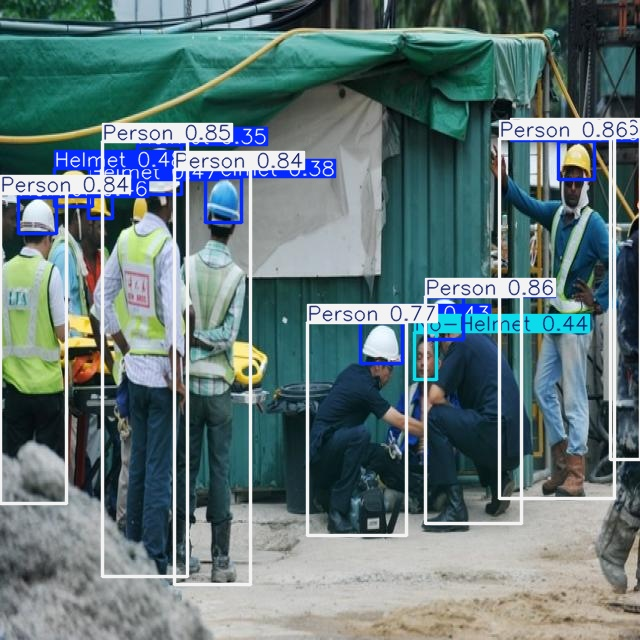

In [5]:
# === Tampilkan hasil inference (jalankan setelah sel Run selesai) ===
from pathlib import Path
from IPython.display import Image, display

pred = Path("runs/infer/predict")
if pred.exists():
    imgs = sorted(p for p in pred.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"})[:8]
    if imgs:
        for p in imgs:
            display(Image(filename=str(p)))
    else:
        print("Tidak ada gambar hasil (kemungkinan sumber berupa video).")
else:
    print("Belum ada hasil inference — jalankan sel Run dulu.")

### Hitungan deteksi per kelas (grafik)
Mem-visualkan jumlah objek per kelas dari ringkasan inference — lebih enak dipresentasikan daripada teks, dan menyorot **No-Helmet** (K3).

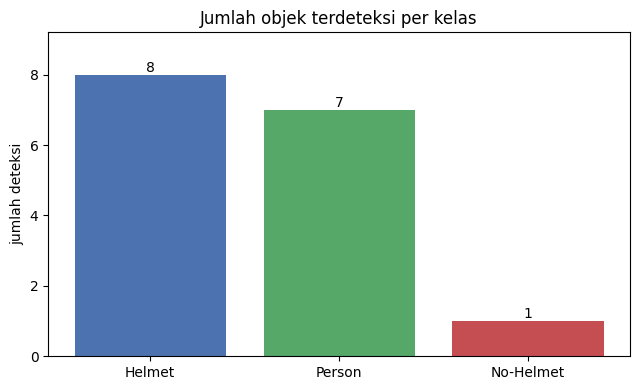

[PERHATIAN K3] 1 objek No-Helmet terdeteksi (potensi pelanggaran).


In [6]:
from pathlib import Path
import re, matplotlib.pyplot as plt
summary = Path("runs/infer/inference_summary.txt")
if not summary.exists():
    print("inference_summary.txt belum ada - jalankan sel Run dulu.")
else:
    counts, grab = {}, False
    for line in summary.read_text(encoding="utf-8").splitlines():
        if "JUMLAH OBJEK TERDETEKSI PER KELAS" in line: grab = True; continue
        if grab:
            m = re.match(r"\s+(.+?)\s*:\s*(\d+)\s*$", line)
            if m and m.group(1).strip().upper() != "TOTAL":
                counts[m.group(1).strip()] = int(m.group(2))
            elif line.strip() == "" and counts:
                break
    if not counts:
        print("Tidak ada objek terdeteksi (atau format ringkasan berbeda).")
    else:
        CLASS_COLORS = {"Helmet": "#4c72b0", "No-Helmet": "#c44e52", "Person": "#55a868"}
        names = list(counts); vals = [counts[n] for n in names]
        fig, ax = plt.subplots(figsize=(6.5, 4))
        b = ax.bar(names, vals, color=[CLASS_COLORS.get(n, "#888") for n in names])
        for bb, v in zip(b, vals): ax.text(bb.get_x()+bb.get_width()/2, v, str(v), ha="center", va="bottom")
        ax.set_title("Jumlah objek terdeteksi per kelas"); ax.set_ylabel("jumlah deteksi"); ax.margins(y=0.15)
        plt.tight_layout(); plt.show()
        if counts.get("No-Helmet", 0) > 0:
            print(f"[PERHATIAN K3] {counts['No-Helmet']} objek No-Helmet terdeteksi (potensi pelanggaran).")